# EDA For The DataSets

## Objectives

- Transform the date column to pandas datetime
- Perform statistical tests to check for hypothesis compatibility
- Look for correlations between the columns in the dataset


## Inputs

CSV file used:

Sales_Combined_Dataset_Visualization.csv


## Outputs

Plots for testing validity of each hypothesis before considering visualisation


## Additional Comments

Developed an experimental ETL library which is in this project (modETL_library.py) 
Has lots of cool features so will be interesting to see how it works "in the field"



In [2]:
#import libraries
import os
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
#added by me for visualisation fine tuning
from matplotlib.ticker import MultipleLocator

#added by me for plotly.express visualisation issue
import nbformat 


#below solution provided by chatGPT 
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root / "assets" / "python_files") not in sys.path:
    sys.path.insert(0, str(project_root / "assets" / "python_files"))
    
import modGlobal
import modETL_Library as modETL
#end solution provided by chatGPT

# Section 1 - Initalisation

## Intitialise All Variables To Be Used In Global Stack 


In [ ]:
#DataFrame variables for EDA
dfSales_Combined_DataSet_Work = None
dfSales_Combined_DataSet_Temp = None
dfSales_Combined_DataSet_Temp1 = None
dfSales_Combined_DataSet_Temp2 = None
dfSales_Combined_DataSet_Grouped = None
dfSales_Combined_DataSet_Merged = None
dfSales_Combined_DataSet_Sample1 = None
dfSales_Combined_DataSet_Sample2 = None

#stores current directory
strCurrentDir = ""

#other vars
intMissingPercent = 0
intMissing = 0
dictDataFrames = dict()
fig = None
axis = None
fltSkew = 0.0
fltKurtosis = 0.0
strTemp = ""
fltShapiroStat = 0.0
fltShapiroP = 0.0
fltMannWhitneyU = 0.0
fltMannWhitneyUStat = 0.0
fltMannWhitneyUp = 0.0
fltTStatistic = 0.0 
fltPValue = 0.0
intStart = 0
intEnd= 0


## Set Current Directory To Base Project Directory


In [4]:
#get project directory - default is jupyter notebook sub folder as that is where this file is located!
#so move back one to the project root path
# Source - https://stackoverflow.com/a/17726833
# Posted by chimpsarehungry
# Retrieved 2026-07-05, License - CC BY-SA 3.0

#get current folder
strCurrentDir = os.getcwd()

#is the last part of the path the project directory?
if not strCurrentDir.endswith(modGlobal.CNST_STR_PROJECT_DIR):
   #get current working directory and move back one to the project root path
   strCurrentDir =  os.path.normpath(os.getcwd() + os.sep + os.pardir)
   os.chdir(os.path.dirname(strCurrentDir))
   #change directory
   os.chdir(strCurrentDir)

#confirm current directory is project directory
print(f"Current Directory: \n {os.getcwd()}")

Current Directory: 
 /Users/rogerwilliams/Projects/Python/CourseProjects/Project2-SalesAnalysis


# Section 2

- Read csv file
- Convert Date column to datetime
- Look at skew, kurtosis and Q-Q plots for ALL columns

Why all columns?

There might be extra insights to be gained by what would normally be a folly as some columns such as Store have
no effect on correlation or variance *individually* but as a data analysist we need to be thorough!



In [5]:
#read file from working files folder
#ETL library returns a dictionary of all files in the folder with the attribute name
#set to the actual csv filename
dictDataFrames = modETL.funcReadVisualisationFilesReturnDictionary()
dfSales_Combined_DataSet_Work = dictDataFrames["Sales_Combined_DataSet_Visualisation.csv"]

4 csv Files Read Into DataFrames

DataFrames Created:
Sales_Combined_DataSet_Visualisation.csv
Features_DataSet_Visualisation.csv
Sales_DataSet_Visualisation.csv
Stores_DataSet_Visualisation.csv




# Transform The Date Column To Pandas Datetime

In [6]:
#convert Date column to pandas datetime
dfSales_Combined_DataSet_Work["Date"] = pd.to_datetime(dfSales_Combined_DataSet_Work["Date"], format="%d/%m/%Y") 

# Get Column Skew/Kurtosis

In [ ]:
#get column skew

modETL.funcGetColumnSkew(dfSales_Combined_DataSet_Work)

# Observations: EDA - Sales Combined DataSet

The skew data shows some interesting results, and potential correlations

Unnamed column can be ignored as that is a pandas crated index, no harm in having a data file indexed will be ignored

Column By Column Analysis:

Store - ignoring this as has numeric effect on the data analysis hence the 0 skew!  
Dept - again ignoring this column  
Date2 - isn't a column in the dataset it is converted to datetime by my ETL library has no meaning here but could in  
another project
Weekly_Sales - highly positively skewed, this is expected as the data is not normally distributed as it is sales value  
               could hypothesise that the highly positively skewed values are good for business!  
IsHoliday - ignored as provides no meaningful insight  
Markdown columns - interesting as start flatlined then exponentailly increase, could provide insights as might be   
                   correlated to sales as is by its nature cost of marketing schemes and promotions                 
Store_Type - ignored as provides no meaningful insight  
Store_Size - as above ignored  
Temperature - as above ignored  
Unemployment - highly positively skewed, could be interesting to see if this is correlated to sales....  
YearMonth - ignored as Feature Engineering for potential visualisation  

The bar chart shows markdown columns as being most skewed which is not surprsing as they are marketing costs and promotions  
so typically need to correlated in order for the values to hve meaning


# Section 3 - Tests For Each Hypothesis

Here we perform these tests:

- Q-Q Plots
- Shapiro-Wilk Test
- Parametric Tests
- Non-Parametric Tests



## Hypothesis 1

Are sales increased if weather is hotter or colder in the last 12 months? 

# Temperature Column Tests

- Test the column on its own
- Test the column in comparision with the Weekly_Sales column as per the hypothesis

In [ ]:
#show Q-Q plot for temperature against Weekly_Sales column
    
#filter data for one year
dfSales_Combined_DataSet_Temp = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work["Date"].dt.year == 2012]
    
#configure plot
fig, axis = plt.subplots(figsize=(6, 6))

#print Q-Q plot for temperature
print("Q-Q Plot For Temperature For 2012")
print("=" * len("Q-Q Plot For Temperature For 2012"))
stats.probplot(dfSales_Combined_DataSet_Work["Temperature"], dist="norm", plot=plt)
plt.title("Q-Q Plot For Temperature", fontweight="bold")
axis.set_xlabel(f"Q-Q Plot For Temperature")
axis.set_ylabel("Theoretical Quantiles")
plt.tight_layout()
plt.show()

# #now repeat using boxplot
print("BoxPlot For Temperature For 2012")
print("=" * len("BoxPlot For Temperature For 2012"))
plt.figure(figsize=(8, 4))
sns.boxplot(x=dfSales_Combined_DataSet_Work["Temperature"])
plt.title("Boxplot For Temperature For 2012", fontweight="bold")
plt.xlabel("Temperature")
plt.tight_layout()
plt.show()

#due to discovery that the scatter plot cant show all 52 weeks in a readable format will split into 
#quarters and show the scatter plot for each quarter of the year
print("Strip Plot For Temperature Against Weekly_Sales For 2012 January To March")
print("=" * len("Strip Plot For Temperature Against Weekly_Sales For 2012 January To March"))
dfSales_Combined_DataSet_Temp = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Date"].between("2012-01-01", "2012-03-31")]
plt.figure(figsize=(30, 12))
sns.stripplot(data=dfSales_Combined_DataSet_Temp, x="Temperature", y="Weekly_Sales", color="black", alpha=0.15, jitter=0.2)
plt.title("Temperature vs Weekly Sales 2012", fontweight="bold")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
           
print()
#Shapiro-Wilk Test for Temperature column using 3000 sample size due to data size
dfSales_Combined_DataSet_Temp = dfSales_Combined_DataSet_Work["Temperature"].sample(3000, random_state=42)
fltShapiroStat, fltShapiroP = stats.shapiro(dfSales_Combined_DataSet_Temp)
print(f"Shapiro-Wilk p-value (Probabilty) Based On Random Sample Of 3000 Records: {fltShapiroP:.4f}")



# Parametric/Non Parametric Tests - Hypothesis 1 - Temperature Column

Will run on Temperature column to see if normally distributed  
If very close to alpha (0.05) this confirms hypothesis Zero else we can continue  
Probably a pointless venture but for consistency will do it anyway!

In [ ]:
#Non Parametric test for Temperature column
dfSales_Combined_DataSet_Temp = dfSales_Combined_DataSet_Work.copy()
#get two samples for two years
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work["Date"].dt.year == 2010]["Temperature"]
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work["Date"].dt.year == 2011]["Temperature"]

dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Temp1.sample(1000, random_state=42)
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp2.sample(1000, random_state=42)

#Mann-Whitney U Test
fltMannWhitneyUStat, fltMannWhitneyUp = stats.mannwhitneyu(dfSales_Combined_DataSet_Temp1, dfSales_Combined_DataSet_Temp2)
print("Non Parametric Test Results For Temperature column For 2010 and 2011")
print("*" * len("Non Parametric Test Results For Temperature column For 2010 and 2011"))
print(f"Mann-Whitney U Test Results: Stat={fltMannWhitneyUStat}, P={fltMannWhitneyUp:.4f}")
print()

#Parametric Individual T-Test for Temperature column for 2010 and 2011 set equal_var to false as not assuming popuation variances are equal
fltStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Temp1, dfSales_Combined_DataSet_Temp2, equal_var = False, nan_policy = "omit")
#print results
print("Individual Parametric Test Results For Temperature column For 2010 and 2011")
print("=" * len("Individual Parametric Test Results For Temperature column For 2010 and 2011"))
print(f"t-statistic: {fltStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()

#run with the alternative set to greater to test if the mean of the first sample is greater than the second sample
#set equal_var to false as not assuming popuation variances are equal
fltTStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Temp1, dfSales_Combined_DataSet_Temp2, equal_var = False, nan_policy = "omit", alternative = "greater")
#print results
print("Individual Parametric Test Results For Temperature Column For 2010 and 2011 Where The Mean Of The First Sample Is Greater Than The Second Sample")
print("=" * len("Individual Parametric Test Results For Temperature Column For 2010 and 2011 Where The Mean Of The First Sample Is Greater Than The Second Sample"))
print(f"t-statistic: {fltTStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")


Non Parametric Test Results For Temperature column For 2010 and 2011
********************************************************************
Mann-Whitney U Test Results: Stat=523768.0, P=0.0657

Individual Parametric Test Results For Temperature column For 2010 and 2011
t-statistic: 1.9959
p-value: 0.0461

Individual Parametric Test Results For Temperature Column For 2010 and 2011 Where The Mean Of The First Sample Is Greater Than The Second Sample
t-statistic: 1.9959
p-value: 0.0230


# Observations: EDA - Sales Combined DataSet - Hypothesis 1 - Temperature Column

The central curve in the data shows a skew away from central tendancy and the initial burst of data is a flatline  
The boxplot shows a large number of values below the median a definite skew   
The strip plot shows a  definite deviation from hypothesis Zero  
These plots confirm hypothesis 1 is viable  
The Shapiro-Wilk Test shows 0! This tells us the data is far from normally distributed so again hypothesis Zero is not met  
The Mann-Whitney U Test was interesting as it showed a p-value of 0.0657 which is greater than the alpha (0.05) based on the  
fact all the other test have disproved hypothesis Zero am happy to ignore   
The Parametric test returns p-values of 0.0461 and 0.0230 which is less than alpha (0.05) which disproves hypothesis Zero

**Note:**  
Based on the fact that Parametric and Non Parametric test are designed to use with TWO different datasets e.g. one with store    
type as A and the other as store type B, and with this hypothesis there is no scenario to use that as Temperature and  
Weekly_Sales and continuous values these tests are merely done for consistency of action


# Weekly_Sales Column Tests

- Test the column on its own
- Don't need to test the column in comparision with the Weekly_Sales column as per the hypothesis as this was done previously  
  in the Temperature column tests

In [ ]:
#show Q-Q plot for Weekly_Sales column
    
#filter data for one year
dfSales_Combined_DataSet_Temp = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work["Date"].dt.year == 2012]
    
#configure plot
fig, axis = plt.subplots(figsize=(6, 6))

#print Q-Q plot for weekly sales
print("Q-Q Plot For Weekly_Sales For 2012")
print("=" * len("Q-Q Plot For Weekly_Sales For 2012"))
stats.probplot(dfSales_Combined_DataSet_Work["Weekly_Sales"], dist="norm", plot=plt)
plt.title("Q-Q Plot For Weekly_Sales", fontweight="bold")
axis.set_xlabel(f"Q-Q Plot For Weekly_Sales")
axis.set_ylabel("Theoretical Quantiles")
plt.tight_layout()
plt.show()

# #now repeat using boxplot
print("BoxPlot For Weekly_Sales For 2012")
print("=" * len("BoxPlot For Weekly_Sales For 2012"))
plt.figure(figsize=(8, 4))
sns.boxplot(x=dfSales_Combined_DataSet_Work["Weekly_Sales"])
plt.title("Boxplot For Weekly_Sales For 2012", fontweight="bold")
plt.xlabel("Weekly Sales")
plt.tight_layout()
plt.show()


print()
#Shapiro-Wilk Test for Weekly_Sales column using 3000 sample size due to data size
dfSales_Combined_DataSet_Temp = dfSales_Combined_DataSet_Work["Weekly_Sales"].sample(3000, random_state=42)
fltShapiroStat, fltShapiroP = stats.shapiro(dfSales_Combined_DataSet_Temp)
print(f"Shapiro-Wilk p-value (Probabilty) Based On Random Sample Of 3000 Records: {fltShapiroP:.4f}")



# Parametric/Non Parametric Tests - Hypothesis 1 - Weekly_Sales Column

Will run on Weekly_Sales column to see if normally distributed  
If very close to alpha (0.05) this confirms hypothesis Zero else we can continue  
Probably a pointless venture but for consistency will do it anyway!

In [ ]:
#Non Parametric test for Temperature column
dfSales_Combined_DataSet_Temp = dfSales_Combined_DataSet_Work.copy()
#get two samples for two years
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Date"].dt.year == 2010]["Weekly_Sales"]
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Date"].dt.year == 2011]["Weekly_Sales"]
#get a nice big sample size
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Temp1.sample(1000, random_state=42)
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp2.sample(1000, random_state=42)

#Mann-Whitney U Test
fltMannWhitneyUStat, fltMannWhitneyUp = stats.mannwhitneyu(dfSales_Combined_DataSet_Temp1, dfSales_Combined_DataSet_Temp2)
print("Non Parametric Test Results For Weekly_Sales column For 2010 and 2011")
print("*" * len("Non Parametric Test Results For Weekly_Sales column For 2010 and 2011"))
print(f"Mann-Whitney U Test Results: Stat={fltMannWhitneyUStat}, P={fltMannWhitneyUp:.4f}")
print()

#Parametric Individual T-Test for Weekly_Sales column for 2010 and 2011 set equal_var to false as not assuming popuation variances are equal
fltStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Temp1, dfSales_Combined_DataSet_Temp2, equal_var = False, nan_policy = "omit")
#print results
print("Independent Parametric Test Results For Weekly_Sales column For 2010 and 2011")
print("=" * len("Independent Parametric Test Results For Weekly_Sales column For 2010 and 2011"))
print(f"t-statistic: {fltStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()

#run with the alternative set to greater to test if the mean of the first sample is greater than the second sample
#set equal_var to false as not assuming popuation variances are equal
fltTStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Temp1, dfSales_Combined_DataSet_Temp2, equal_var = False, nan_policy = "omit", alternative = "greater")
#print results
print("Independent Parametric Test Results For Weekly_Sales Column For 2010 and 2011 Where The Mean Of The First Sample Is Greater Than The Second Sample")
print("=" * len("Independent Parametric Test Results For Weekly_Sales Column For 2010 and 2011 Where The Mean Of The First Sample Is Greater Than The Second Sample"))
print(f"t-statistic: {fltTStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")

#print mean sales
print(f"Weekly Sales For Sample 1 Mean Sales (2010): £{dfSales_Combined_DataSet_Sample1.mean():,.2f}")
print(f"Weekly Sales For Sample 2 Mean Sales (2011): £{dfSales_Combined_DataSet_Sample2.mean():,.2f}")


Non Parametric Test Results For Weekly_Sales column For 2010 and 2011
*********************************************************************
Mann-Whitney U Test Results: Stat=504211.0, P=0.7444

Independent Parametric Test Results For Weekly_Sales column For 2010 and 2011
t-statistic: 0.5705
p-value: 0.5684

Independent Parametric Test Results For Weekly_Sales Column For 2010 and 2011 Where The Mean Of The First Sample Is Greater Than The Second Sample
t-statistic: 0.5705
p-value: 0.2842


# Observations: EDA - Sales Combined DataSet - Hypothesis 1 - Weekly_Sales Column

The central curve in the data shows a massive skew away from central tendancy and the initial burst of data is relatively  
stable  
The boxplot shows a large number of outliers and a definite skew which correlates with the Q-Q plot 
These basic plots confirm hypothesis 1 is viable  
The Shapiro-Wilk Test shows 0! This tells us the data is far from normally distributed so again hypothesis Zero is not met  
The Mann-Whitney U Test was interesting as it showed a p-value of 0.7444 which is greater than the alpha (0.05) based on the  
fact all the other test have disproved hypothesis Zero am happy to ignore   
The Parametric tests return p-values of 0.2842 and 0.05684 which is greater than alpha (0.05) which proves hypothesis Zero  
Yet all the other tests have disproved hypothesis Zero so am happy to ignore this result 


**Note:**  
Based on the fact that Parametric and Non Parametric tests are designed to work with TWO different dataset variations e.g. one  
with store type as A and the other as store type B, and with this hypothesis there is no scenario to use that as Temperature  
and Weekly_Sales are continuous values thus these tests are merely done for consistency of action

# Final Observations: EDA - Sales Combined DataSet - Hypothesis 1

Based on the Q-Q plots it is clear that hypothesis Zero is *not* met also the strip plot comparing Weekly_Sales against  
Temperature shows a definite skew away from central tendancy which is further proof hypothesis Zero is *not* met
The Parametric test where void as the hypothesis did not meet the criteria they are designed for but again for consistency  
of action they where done anyway 

# Hypothesis 2

Sales differences between holiday and non-holiday weeks per store in the last 12 months

# Tests

- Because IsHoliday is boolean nothing of any value (pun intended) can be gleaned from running any tests on its values  
  so will skip them
- No need to run Q-Q plots as already done in previous tests for Temperature column  
- Because Weekly_Sales is a continuous value we can run the Parametric tests! 
- Show violin plot for distribution for all rows then for one year

# Parametric/Non Parametric Tests - Hypothesis 2

Will run on Weekly_Sales column comparing when IsHoliday is true/false to see if normally distributed  
If very close to alpha (0.05) this confirms hypothesis Zero else we can continue  


In [ ]:
#Non Parametric test for Weekly_Sales column
dfSales_Combined_DataSet_Temp = dfSales_Combined_DataSet_Work.copy()

#get two samples for two years
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["IsHoliday"] == True]["Weekly_Sales"]
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["IsHoliday"] == False]["Weekly_Sales"]
#get a nice big sample size
dfSales_Combined_DataSet_Sample1 = dfSales_Combined_DataSet_Temp1.sample(3000, random_state=42)
dfSales_Combined_DataSet_Sample2 = dfSales_Combined_DataSet_Temp2.sample(3000, random_state=42)

#Mann-Whitney U Test
fltMannWhitneyUStat, fltMannWhitneyUp = stats.mannwhitneyu(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2)
print("Non Parametric Test Results For Weekly_Sales Where IsHoliday Is True And False")
print("*" * len("Non Parametric Test Results For Weekly_Sales Where IsHoliday Is True And False"))
print(f"Mann-Whitney U Test Results: Stat={fltMannWhitneyUStat}, P={fltMannWhitneyUp:.4f}")
print()

#Parametric Independent T-Test datasets where IsHoliday is true and false set equal_var to false as not assuming popuation variances are equal
fltStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit")
#print results
print("Independent Parametric Test Results For Weekly_Sales Where IsHoliday Is True And False")
print("=" * len("Independent Parametric Test Results For Weekly_Sales Where IsHoliday Is True And False"))
print(f"t-statistic: {fltStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()

#run with the alternative set to greater to test if the mean of the first sample is greater than the second sample
#set equal_var to false as not assuming popuation variances are equal
fltTStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit", alternative = "greater")
#print results
print("Independent Parametric Test Results For Weekly_Sales Where IsHoliday Is True And False")
print("=" * len("Independent Parametric Test Results For Weekly_Sales Where IsHoliday Is True And False"))
print(f"t-statistic: {fltTStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()
#print mean sales
print(f"Holiday Weeks Sample 1 Mean Sales: £{dfSales_Combined_DataSet_Sample1.mean():,.2f}")
print(f"Non-Holiday Weeks Sample 2 Mean Sales: £{dfSales_Combined_DataSet_Sample2.mean():,.2f}")

#show violin plot for distribution
plt.figure(figsize=(6, 10))
sns.violinplot(data=dfSales_Combined_DataSet_Work, x="IsHoliday", y="Weekly_Sales")
plt.title("Weekly Sales Where Holiday Is True/False All Rows", fontweight="bold")
plt.xlabel("IsHoliday")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#repeat but this time show the distribution based on ONE year of data
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work["Date"].dt.year == 2012][["Weekly_Sales","IsHoliday"]]

#show violin plot for distribution
plt.figure(figsize=(6, 10))
sns.violinplot(data=dfSales_Combined_DataSet_Temp1, x="IsHoliday", y="Weekly_Sales")
plt.title("Weekly Sales Where Holiday Is True/False For 2010", fontweight="bold")
plt.xlabel("IsHoliday")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
          

# Observations: EDA - Sales Combined DataSet - Hypothesis 2 - Weekly_Sales Against IsHoliday

The Shapiro-Wilk Test is not included as was done in previous Temperature tests 
The Mann-Whitney U Test was interesting as it showed a p-value of 0.1598 which is greater than the alpha (0.05) which means 
hypothesis Zero is met!  
The Parametric tests return p-values of 0.0213 and 0.0107 which is lower than alpha (0.05) which disproves hypothesis Zero  
The first violin plot clearly shows a skew away from central tendancy which is further proof hypothesis Zero is *not* met plus  
some mighty outliers. 
The second filtered by just one year shows a similar skew away from central tendancy  

Based on these findings I am happy to ignore the Mann-Whitney U Test results

# Final Observations: EDA - Sales Combined DataSet - Hypothesis 2

Having appropriate column data to perform the Parametric test was a great bonus as they as usually key ingredients in  
understanding hypothesis validity  

The plots prove hypothesis 2 is visable for pursuit


# Hypothesis 3

What is most profitable store type in the last 12 months?

# Tests

- Because Store_Type is numerical and not continuous we can run the Parametric tests 
- No need to run Q-Q plots for Store_Type as would provide no insights
- Show violin plots for distribution for all rows and then for one year

# Parametric/Non Parametric Tests - Hypothesis 3

Will run on Weekly_Sales column comparing Store_Type to see if normally distributed  
If very close to alpha (0.05) this confirms hypothesis Zero else we can continue  


In [ ]:
#Non Parametric test for Weekly_Sales column
dfSales_Combined_DataSet_Temp = dfSales_Combined_DataSet_Work.copy()
#get two samples for store types 1 & 2
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Store_Type"] == 1]["Weekly_Sales"]
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Store_Type"] == 2]["Weekly_Sales"]
#get a nice big sample size
dfSales_Combined_DataSet_Sample1 = dfSales_Combined_DataSet_Temp1.sample(1000, random_state=42)
dfSales_Combined_DataSet_Sample2 = dfSales_Combined_DataSet_Temp2.sample(1000, random_state=42)

#Mann-Whitney U Test
fltMannWhitneyUStat, fltMannWhitneyUp = stats.mannwhitneyu(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2)
print("Non Parametric Test Results For Weekly_Sales Where Store_Type Is 1 And 2")
print("*" * len("Non Parametric Test Results For Weekly_Sales Where Store_Type Is 1 And 2"))
print(f"Mann-Whitney U Test Results:")
print(f"Stat={fltMannWhitneyUStat}")
print(f"P={fltMannWhitneyUp:.4f}")
print()

# #Parametric Independent T-Test datasets where IsHoliday is true and false set equal_var to false as not assuming popuation variances are equal
fltStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit")
#print results
print("Independent Parametric Test Results For Weekly_Sales Where Store_Type Is 1 And 2")
print("=" * len("Independent Parametric Test Results For Weekly_Sales Where Store_Type Is 1 And 2"))
print(f"t-statistic: {fltStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()

# #run with the alternative set to greater to test if the mean of the first sample is greater than the second sample
# #set equal_var to false as not assuming popuation variances are equal
fltTStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit", alternative = "greater")
#print results
print("Independent Parametric Test Results For Weekly_Sales All Store_Types")
print("=" * len("Independent Parametric Test Results For Weekly_Sales Where All Store_Types"))
print(f"t-statistic: {fltTStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()
#print mean sales
print(f"Store Type Sample 1 Mean Sales: £{dfSales_Combined_DataSet_Sample1.mean():,.2f}")
print(f"Store Type Sample 2 Mean Sales: £{dfSales_Combined_DataSet_Sample2.mean():,.2f}")

# #show violin plot for distribution
plt.figure(figsize=(6, 10))
sns.violinplot(data=dfSales_Combined_DataSet_Work, x="Store_Type", y="Weekly_Sales")
plt.title("Weekly Sales Where Store Type All Rows", fontweight="bold")
plt.xlabel("Store Type")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# #repeat but this time show the distribution based on ONE year of data
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work["Date"].dt.year == 2012][["Weekly_Sales","Store_Type"]]

# #show violin plot for distribution 
plt.figure(figsize=(6, 10))
sns.violinplot(data=dfSales_Combined_DataSet_Temp1, x="Store_Type", y="Weekly_Sales")
plt.title("Weekly Sales For Store Type 2012", fontweight="bold")
plt.xlabel("Store Type")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
        
        

# Observations: EDA - Sales Combined DataSet - Hypothesis 3 - Weekly_Sales Against Store_Type 

The Shapiro-Wilk Test is not included as was done in previous Temperature tests 
The Mann-Whitney U Test was interesting as it showed a p-value of 0.000 which is lower than the alpha (0.05) which means 
hypothesis Zero is not met  
The Parametric tests return p-values of 0.0000 and 0.0000 which is lower than alpha (0.05) which disproves hypothesis Zero  
The first violin plot clearly shows a skew away from central tendancy which is further proof hypothesis Zero is *not* met plus  
some mighty outliers. 
The second filtered by just one year shows a similar skew away from central tendancy  

One common trait - lots of outliers at the higher value range  



# Final Observations: EDA - Sales Combined DataSet - Hypothesis 3

Having appropriate column data to perform the Parametric test was a great bonus as they as usually key ingredients in  
understanding hypothesis validity  

The plots prove hypothesis 3 is visable for pursuit

# Hypothesis 4

Does store size affect profitability? If so, how much in the last 12 months?

# Tests

- Because Store_Size is numerical and continuous Parametric tests will be meaningless but will run them anyway for consistency of action   
- No need to run Q-Q plots for Store_Size as would provide no insights
- Show violin plot for distribution for all rows then for one year

# Parametric/Non Parametric Tests - Hypothesis 4

Will run on Weekly_Sales column comparing Store_Size to see if normally distributed  
If very close to alpha (0.05) this confirms hypothesis Zero else we can continue  

In [ ]:
#Non Parametric test for Weekly_Sales column
dfSales_Combined_DataSet_Temp = dfSales_Combined_DataSet_Work.copy()
#get two samples for store types 1 & 2
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Store_Size"] <= 100000]["Weekly_Sales"]
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Store_Size"] > 100000]["Weekly_Sales"]

#get a nice big sample size
dfSales_Combined_DataSet_Sample1 = dfSales_Combined_DataSet_Temp1.sample(3000, random_state=42)
dfSales_Combined_DataSet_Sample2 = dfSales_Combined_DataSet_Temp2.sample(3000, random_state=42)

#Mann-Whitney U Test
fltMannWhitneyUStat, fltMannWhitneyUp = stats.mannwhitneyu(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2)
print("Non Parametric Test Results For Weekly_Sales With Store_Size")
print("*" * len("Non Parametric Test Results For Weekly_Sales With Store_Size"))
print(f"Mann-Whitney U Test Results:")
print(f"Stat={fltMannWhitneyUStat}")
print(f"P={fltMannWhitneyUp:.4f}")
print()

# #Parametric Independent T-Test datasets where IsHoliday is true and false set equal_var to false as not assuming popuation variances are equal
fltStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit")
#print results
print("Independent Parametric Test Results For Weekly_Sales With Store_Size")
print("=" * len("Independent Parametric Test Results For Weekly_Sales With Store_Size"))
print(f"t-statistic: {fltStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()

# #run with the alternative set to greater to test if the mean of the first sample is greater than the second sample
# #set equal_var to false as not assuming popuation variances are equal
fltTStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit", alternative = "greater")
#print results
print("Independent Parametric Test Results For Weekly_Sales With Store_Size")
print("=" * len("Independent Parametric Test Results For Weekly_Sales With Store_Size"))
print(f"t-statistic: {fltTStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()
#print mean sales
print(f"Store Size Sample 1 Mean Sales: £{dfSales_Combined_DataSet_Sample1.mean():,.2f}")
print(f"Store Size Sample 2 Mean Sales: £{dfSales_Combined_DataSet_Sample2.mean():,.2f}")

#repeat but this time show the distribution based on ONE year of data
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work["Date"].dt.year == 2012][["Weekly_Sales","Store_Size"]]

# #show violin plot for distribution 
plt.figure(figsize=(30, 10))
sns.violinplot(data=dfSales_Combined_DataSet_Temp1, x="Store_Size", y="Weekly_Sales")
plt.title("Weekly Sales With Store Size 2012", fontweight="bold")
plt.xlabel("Store Size")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
        
        

# Observations: EDA - Sales Combined DataSet - Hypothesis 4 - Weekly_Sales Against Store_Size

The Shapiro-Wilk Test is not included as was done in previous Temperature tests 
The Mann-Whitney U Test was interesting as it showed a p-value of 0.0000 which is less than the alpha (0.05) which means 
hypothesis Zero is not met  
The Parametric tests return p-values of 0.0000 which is lower than alpha (0.05) disproves hypothesis Zero and 1.0000 which  
is higher and proves hypothesis Zero  
The first violin plot clearly shows a skew away from central tendancy which is further proof hypothesis Zero is *not* met plus  
some mighty outliers. 
The second filtered by just one year shows a similar skew away from central tendancy
One common trait - lots of outliers  

Based on these findings I am happy to believe hypothesis Zero is **not** met 


# Final Observations: EDA - Sales Combined DataSet - Hypothesis 4

Having appropriate column data to perform the Parametric test was a great bonus as they as usually key ingredients in  
understanding hypothesis validity  

The plots prove hypothesis 4 is visable for pursuit

# Hypothesis 5

Show Weekly Sales by Store, Store Type and Department Last 12 Months


# Tests

- Because Store_Type is numerical and not continuous so Parametric tests will be run  
- Also Store matches the above criteria so Parametric tests will be run
- No need to run Q-Q plots for Department as would provide no insights
- Show violin plot for distribution for all rows then for one year

# Parametric/Non Parametric Tests - Hypothesis 5

Will run on Weekly_Sales column comparing Store_Type to see if normally distributed  
As a bonus will run test to compare Weekly_Sales and Department could be interesting...  
If very close to alpha (0.05) this confirms hypothesis Zero else we can continue  

In [ ]:
#Non Parametric test for Weekly_Sales column
dfSales_Combined_DataSet_Temp = dfSales_Combined_DataSet_Work.copy()
#get two samples for store types 1 & 2
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Store_Type"] == 1]["Weekly_Sales"]
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Store_Type"] == 2]["Weekly_Sales"]

#get a nice big sample size
dfSales_Combined_DataSet_Sample1 = dfSales_Combined_DataSet_Temp1.sample(3000, random_state=42)
dfSales_Combined_DataSet_Sample2 = dfSales_Combined_DataSet_Temp2.sample(3000, random_state=42)

#Mann-Whitney U Test
fltMannWhitneyUStat, fltMannWhitneyUp = stats.mannwhitneyu(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2)
print("Non Parametric Test Results For Weekly_Sales With Store_Type")
print("*" * len("Non Parametric Test Results For Weekly_Sales With Store_Type"))
print(f"Mann-Whitney U Test Results:")
print(f"Stat={fltMannWhitneyUStat}")
print(f"P={fltMannWhitneyUp:.4f}")
print()

# #Parametric Independent T-Test datasets where IsHoliday is true and false set equal_var to false as not assuming popuation variances are equal
fltStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit")
#print results
print("Independent Parametric Test Results For Weekly_Sales With Store_Type")
print("=" * len("Independent Parametric Test Results For Weekly_Sales With Store_Type"))
print(f"t-statistic: {fltStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()

# #run with the alternative set to greater to test if the mean of the first sample is greater than the second sample
# #set equal_var to false as not assuming popuation variances are equal
fltTStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit", alternative = "greater")
#print results
print("Independent Parametric Test Results For Weekly_Sales With Store_Type")
print("=" * len("Independent Parametric Test Results For Weekly_Sales With Store_Type"))
print(f"t-statistic: {fltTStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()
#print mean sales
print(f"Store Type Sample 1 Mean Sales: £{dfSales_Combined_DataSet_Sample1.mean():,.2f}")
print(f"Store Type Sample 2 Mean Sales: £{dfSales_Combined_DataSet_Sample2.mean():,.2f}")

# #show violin plot for distribution
plt.figure(figsize=(12, 10))
sns.violinplot(data=dfSales_Combined_DataSet_Work, x="Store_Type", y="Weekly_Sales")
plt.title("Weekly Sales With Store Type All Rows", fontweight="bold")
plt.xlabel("Store Type")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# #repeat but this time show the distribution based on ONE year of data
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work["Date"].dt.year == 2012][["Weekly_Sales","Store_Type"]]

# #show violin plot for distribution 
plt.figure(figsize=(12, 6))
sns.violinplot(data=dfSales_Combined_DataSet_Temp1, x="Store_Type", y="Weekly_Sales")
plt.title("Weekly Sales With Store Type 2012", fontweight="bold")
plt.xlabel("Store Type")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
              
        

#Run Same Tests But This Time Pivot On Department


In [ ]:
#Non Parametric test for Weekly_Sales column
dfSales_Combined_DataSet_Temp = dfSales_Combined_DataSet_Work.copy()
#get two samples for departments 1 & 2
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Dept"] <= 1]["Weekly_Sales"]
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Dept"] > 2]["Weekly_Sales"]

#get a nice big sample size
dfSales_Combined_DataSet_Sample1 = dfSales_Combined_DataSet_Temp1.sample(3000, random_state=42)
dfSales_Combined_DataSet_Sample2 = dfSales_Combined_DataSet_Temp2.sample(3000, random_state=42)

#Mann-Whitney U Test
fltMannWhitneyUStat, fltMannWhitneyUp = stats.mannwhitneyu(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2)
print("Non Parametric Test Results For Weekly_Sales With Dept")
print("*" * len("Non Parametric Test Results For Weekly_Sales With Dept"))
print(f"Mann-Whitney U Test Results:")
print(f"Stat={fltMannWhitneyUStat}")
print(f"P={fltMannWhitneyUp:.4f}")
print()

# #Parametric Independent T-Test datasets where IsHoliday is true and false set equal_var to false as not assuming popuation variances are equal
fltStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit")
#print results
print("Independent Parametric Test Results For Weekly_Sales With Dept")
print("=" * len("Independent Parametric Test Results For Weekly_Sales With Dept"))
print(f"t-statistic: {fltStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()

# #run with the alternative set to greater to test if the mean of the first sample is greater than the second sample
# #set equal_var to false as not assuming popuation variances are equal
fltTStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit", alternative = "greater")
#print results
print("Independent Parametric Test Results For Weekly_Sales With Dept")
print("=" * len("Independent Parametric Test Results For Weekly_Sales With Dept"))
print(f"t-statistic: {fltTStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()
#print mean sales
print(f"Dept Sample 1 Mean Sales: £{dfSales_Combined_DataSet_Sample1.mean():,.2f}")
print(f"Dept Sample 2 Mean Sales: £{dfSales_Combined_DataSet_Sample2.mean():,.2f}")

# #show violin plot for distribution
plt.figure(figsize=(20, 10))
sns.violinplot(data=dfSales_Combined_DataSet_Work, x="Dept", y="Weekly_Sales")
plt.title("Weekly Sales With Dept All Rows", fontweight="bold")
plt.xlabel("Dept")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#repeat but this time show the distribution based on ONE year of data
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work["Date"].dt.year == 2012][["Weekly_Sales","Dept"]]

# #show violin plot for distribution 

#99 departments for look at!
for intNum in range(5, 99, 5):
    if intNum == 5:
       intStart = 1
    else:
       intStart = intNum - 4
            
    intEnd = intNum
    dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[ dfSales_Combined_DataSet_Temp["Dept"].between(intStart, intEnd)]               
    #plot for Dept 1-45
    plt.figure(figsize=(12, 6))
    sns.violinplot(data=dfSales_Combined_DataSet_Temp2, x="Dept", y="Weekly_Sales")
    plt.title("Weekly Sales With Dept 2012", fontweight="bold")
    plt.xlabel("Dept")
    plt.ylabel("Weekly Sales")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()  

#show last departments
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[ dfSales_Combined_DataSet_Temp["Dept"].between(91,95)]               
#plot for Dept 1-45
plt.figure(figsize=(12, 6))
sns.violinplot(data=dfSales_Combined_DataSet_Temp2, x="Dept", y="Weekly_Sales")
plt.title("Weekly Sales With Dept 2012", fontweight="bold")
plt.xlabel("Dept")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()  
              
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[ dfSales_Combined_DataSet_Temp["Dept"] > 96]               
#plot for Dept 1-45
plt.figure(figsize=(12, 6))
sns.violinplot(data=dfSales_Combined_DataSet_Temp2, x="Dept", y="Weekly_Sales")
plt.title("Weekly Sales With Dept 2012", fontweight="bold")
plt.xlabel("Dept")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()  
          

# Observations: EDA - Sales Combined DataSet - Hypothesis 5 - Weekly_Sales Against Store_Size, Store_Type and Department

By Store_Type:  

The Shapiro-Wilk Test is not included as was done in previous Temperature tests 
The Mann-Whitney U Test was interesting as it showed a p-value of 0.0000 which is less than the alpha (0.05) which means 
hypothesis Zero is not met  
The Parametric tests return p-values of 0.0000 and 0.0000 which is lower than alpha (0.05) disproves hypothesis Zero  
The first violin plot clearly shows a skew away from central tendancy which is further proof hypothesis Zero is *not* met plus  
some mighty outliers. 
The second filtered by just one year shows a similar skew away from central tendancy
Due to the sheer volume of departments it is hard to show the box plots 
One common trait - lots of outliers  


By Dept:  

The Shapiro-Wilk Test is not included as was done in previous Temperature tests 
The Mann-Whitney U Test was interesting as it showed a p-value of 0.0000 which is less than the alpha (0.05) which means 
hypothesis Zero is not met  
The Parametric tests return p-values of 0.0000 and 0.0000which is lower than alpha (0.05) disproves hypothesis Zero 
The first violin plot clearly shows a skew away from central tendancy which is further proof hypothesis Zero is *not* met plus  
some mighty outliers. 
The second filtered by just one year per deparment shows a similar skew away from central tendancy   

One common trait - lots of outliers  

Based on these findings I am happy to believe hypothesis Zero is **not** met 


# Final Observations: EDA - Sales Combined DataSet - Hypothesis 5

Having appropriate column data to perform the Parametric test was a great bonus as they as usually key ingredients in  
understanding hypothesis validity  

The plots prove hypothesis 5 is visable for pursuit


# Hyptothesis 6

Impact of markdowns on sales during holiday periods in the last 12 months by store

# Tests

- Because the MarkDown columns are numerical and continuous so Parametric tests will be meaningless so will ignore them 
- Also Store matches the criteria for Parametric test so Parametric tests will be run pivoting on Store_Type and InHoliday  
  equals true so we can see InHoliday true sales distribution
- Show violin plot for distribution for all rows then for one year

# Parametric/Non Parametric Tests - Hypothesis 6

Will run on Weekly_Sales column comparing Store_Type to see if normally distributed  
As a bonus will run test to compare Weekly_Sales and Department could be interesting...  
If very close to alpha (0.05) this confirms hypothesis Zero else we can continue 

Non Parametric Test Results For Weekly_Sales With InHoliday True And False
**************************************************************************
Mann-Whitney U Test Results:
Stat=4594315.0
P=0.1598

Independent Parametric Test Results For Weekly_Sales With InHoliday True And False
t-statistic: 2.3030
p-value: 0.0213

Independent Parametric Test Results For Weekly_Sales With InHoliday True And False
t-statistic: 2.3030
p-value: 0.0107

Store Type Sample 1 Mean Sales: £17,580.13
Store Type Sample 2 Mean Sales: £16,088.25


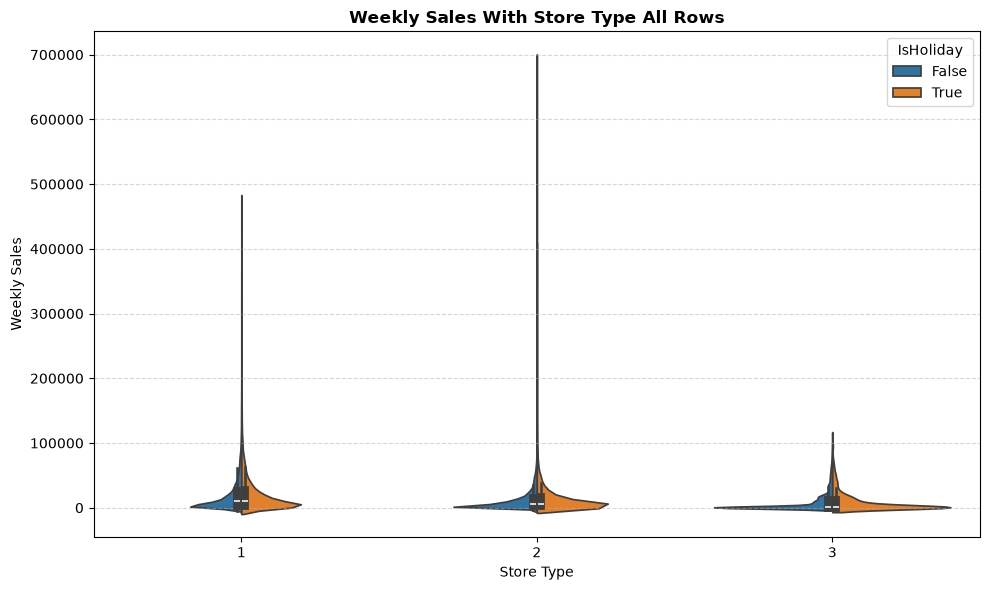

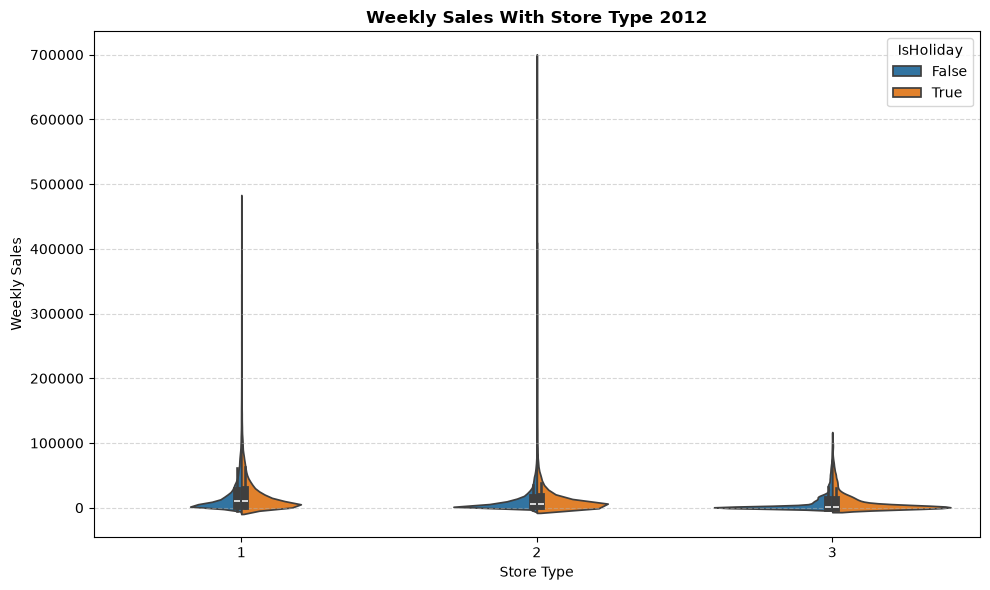

In [85]:
##Non Parametric test for Weekly_Sales column
dfSales_Combined_DataSet_Temp = dfSales_Combined_DataSet_Work.copy()
#get two samples for store types 1 & 2
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["IsHoliday"] == True]["Weekly_Sales"]
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["IsHoliday"] == False]["Weekly_Sales"]

#get a nice big sample size
dfSales_Combined_DataSet_Sample1 = dfSales_Combined_DataSet_Temp1.sample(3000, random_state=42)
dfSales_Combined_DataSet_Sample2 = dfSales_Combined_DataSet_Temp2.sample(3000, random_state=42)

#Mann-Whitney U Test
fltMannWhitneyUStat, fltMannWhitneyUp = stats.mannwhitneyu(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2)
print("Non Parametric Test Results For Weekly_Sales With InHoliday True And False")
print("*" * len("Non Parametric Test Results For Weekly_Sales With InHoliday True And False"))
print(f"Mann-Whitney U Test Results:")
print(f"Stat={fltMannWhitneyUStat}")
print(f"P={fltMannWhitneyUp:.4f}")
print()

# #Parametric Independent T-Test datasets where IsHoliday is true and false set equal_var to false as not assuming popuation variances are equal
fltStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit")
#print results
print("Independent Parametric Test Results For Weekly_Sales With InHoliday True And False")
print("=" * len("Independent Parametric Test Results For Weekly_Sales With InHoliday True And False"))
print(f"t-statistic: {fltStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()

# #run with the alternative set to greater to test if the mean of the first sample is greater than the second sample
# #set equal_var to false as not assuming popuation variances are equal
fltTStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit", alternative = "greater")
#print results
print("Independent Parametric Test Results For Weekly_Sales With InHoliday True And False")
print("=" * len("Independent Parametric Test Results For Weekly_Sales With InHoliday True And False"))
print(f"t-statistic: {fltTStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()
#print mean sales
print(f"Store Type Sample 1 Mean Sales: £{dfSales_Combined_DataSet_Sample1.mean():,.2f}")
print(f"Store Type Sample 2 Mean Sales: £{dfSales_Combined_DataSet_Sample2.mean():,.2f}")

# #show violin plot for distribution
plt.figure(figsize=(10, 6))
sns.violinplot(data=dfSales_Combined_DataSet_Work, x="Store_Type", y="Weekly_Sales", hue="IsHoliday", split=True)
plt.title("Weekly Sales With Store Type All Rows", fontweight="bold")
plt.xlabel("Store Type")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# #repeat but this time show the distribution based on ONE year of data
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Work[dfSales_Combined_DataSet_Work["Date"].dt.year == 2012][["Weekly_Sales","Store_Type"]]

# #show violin plot for distribution 
plt.figure(figsize=(10, 6))
sns.violinplot(data=dfSales_Combined_DataSet_Work, x="Store_Type", y="Weekly_Sales", hue="IsHoliday", split=True)
plt.title("Weekly Sales With Store Type 2012", fontweight="bold")
plt.xlabel("Store Type")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
              
        

# Observations: EDA - Sales Combined DataSet - Hypothesis 6 - Weekly_Sales Against Store_Size, Store_Type and Department

By Store_Type:  

The Shapiro-Wilk Test is not included as was done in previous Temperature tests 
The Mann-Whitney U Test was interesting as it showed a p-value of 0.1598 which is greater than the alpha (0.05) which means 
hypothesis Zero is met!  
The Parametric tests return p-values of 0.0213 and 0.0107 which is lower than alpha (0.05) disproves hypothesis Zero  
The first violin plot clearly shows a skew away from central tendancy which is further proof hypothesis Zero is *not* met plus  
some mighty outliers. 
The second filtered by just one year shows a similar skew away from central tendancy
Due to the sheer volume of departments it is hard to show the box plots  

One common trait - lots of outliers  


# Final Observations: EDA - Sales Combined DataSet - Hypothesis 6

Having appropriate column data to perform the Parametric test was a great bonus as they as usually key ingredients in  
understanding hypothesis validity  

The plots prove hypothesis 6 is visable for pursuit

# EDL Conclusion

- All hypothesis stand as being viable for visualisation 
- Running both Parametric and Non Parametric test allowed a comparison between the different styles which allows a more  
  informed judgement as to whether the hypothesis is viable or whether hypothesis Zero is met